# Tarefa 4: Interpretação de Resultados e Insights

Análise consolidada dos modelos treinados, teste estatístico entre os melhores candidatos e extração de insights para a classificação de grãos de trigo em cooperativas agrícolas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy import stats

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')
features = [c for c in train.columns if c != 'variety']
X_train, y_train = train[features], train['variety']
X_test, y_test = test[features], test['variety']

models = {
    'KNN': joblib.load(MODELS_DIR / 'knn_optimized.pkl'),
    'SVM': joblib.load(MODELS_DIR / 'svm_optimized.pkl'),
    'Random Forest': joblib.load(MODELS_DIR / 'random_forest_optimized.pkl'),
    'Logistic Regression': joblib.load(MODELS_DIR / 'logistic_regression_optimized.pkl'),
    'Naive Bayes': joblib.load(MODELS_DIR / 'naive_bayes_base.pkl')
}

test_scores = {}
for name, model in models.items():
    test_scores[name] = accuracy_score(y_test, model.predict(X_test))

final_df = pd.DataFrame({
    'Modelo': list(models.keys()),
    'Acurácia no Teste': [test_scores[m] for m in models.keys()]
}).sort_values('Acurácia no Teste', ascending=False)
final_df.round(4)

,Modelo,Acurácia no Teste
3,Logistic Regression,0.9048
1,SVM,0.8889
0,KNN,0.8730
2,Random Forest,0.8413
4,Naive Bayes,0.8413


## Teste estatístico entre os dois melhores modelos (Validação Cruzada)

Utilizamos o teste t pareado sobre acurácias de 10 folds estratificados para verificar se a diferença entre Logistic Regression e SVM é estatisticamente significativa.

In [2]:
top1, top2 = final_df.iloc[0]['Modelo'], final_df.iloc[1]['Modelo']
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_top1 = cross_val_score(models[top1], X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
scores_top2 = cross_val_score(models[top2], X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)

t_stat, p_value = stats.ttest_rel(scores_top1, scores_top2)

print(f'{top1}: mean={scores_top1.mean():.4f}, std={scores_top1.std():.4f}')
print(f'{top2}: mean={scores_top2.mean():.4f}, std={scores_top2.std():.4f}')
print(f't-statistic: {t_stat:.4f}, p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Diferença estatisticamente significativa (p < 0.05)')
else:
    print('Não há diferença estatisticamente significativa (p >= 0.05)')

Logistic Regression: mean=0.9729, std=0.0447
SVM: mean=0.9662, std=0.0338
t-statistic: 0.5571, p-value: 0.5911
Não há diferença estatisticamente significativa (p >= 0.05)


## Importância das características (Random Forest)

A importância é extraída do modelo otimizado e apresentada em ordem decrescente, sem reinterpretação.

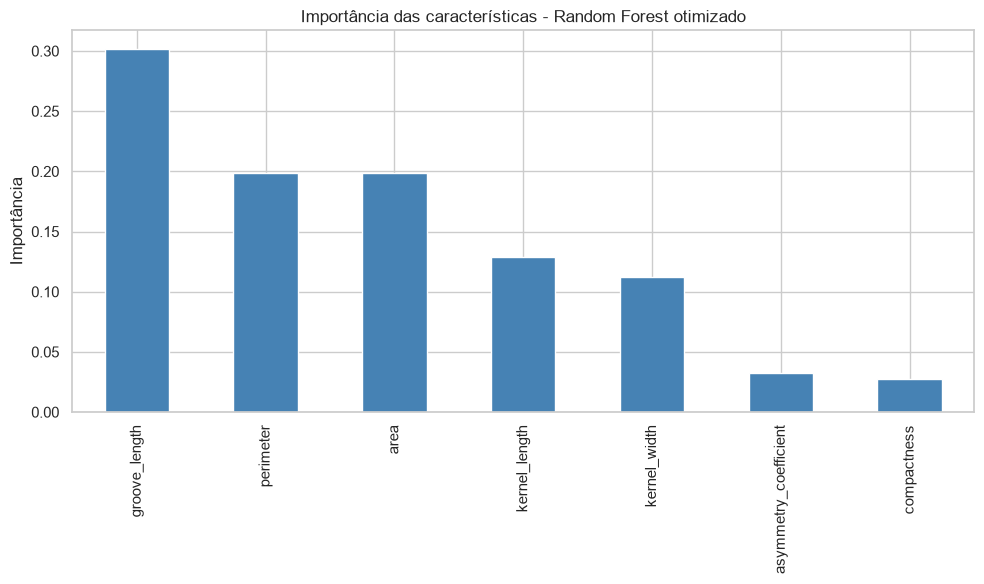

groove_length            0.3019
perimeter                0.1988
area                     0.1983
kernel_length            0.1292
kernel_width             0.1118
asymmetry_coefficient    0.0328
compactness              0.0272
dtype: float64

In [3]:
rf = models['Random Forest']
importances = pd.Series(rf.named_steps['model'].feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Importância das características - Random Forest otimizado')
plt.ylabel('Importância')
plt.tight_layout()
plt.show()
importances.round(4)

## Coeficientes da Regressão Logística

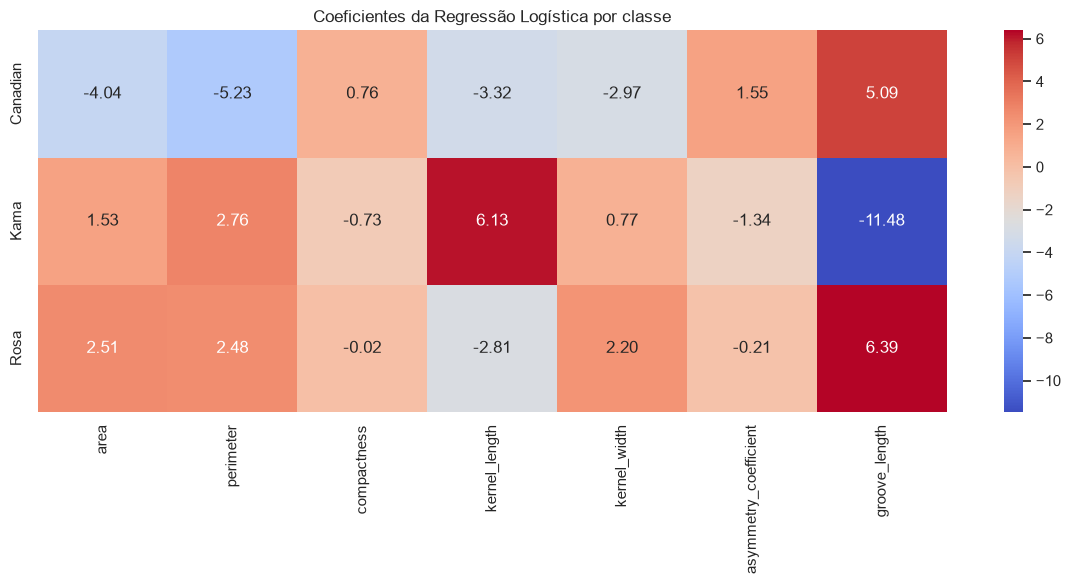

In [4]:
logreg = models['Logistic Regression']
coef = logreg.named_steps['model'].coef_
coef_df = pd.DataFrame(coef, columns=features, index=logreg.named_steps['model'].classes_)
plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Coeficientes da Regressão Logística por classe')
plt.tight_layout()
plt.show()

## Análise de erros do melhor modelo

Melhor modelo no teste: Logistic Regression
              precision    recall  f1-score   support

    Canadian       0.90      0.90      0.90        21
        Kama       0.86      0.86      0.86        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.90        63
   macro avg       0.90      0.90      0.90        63
weighted avg       0.90      0.90      0.90        63



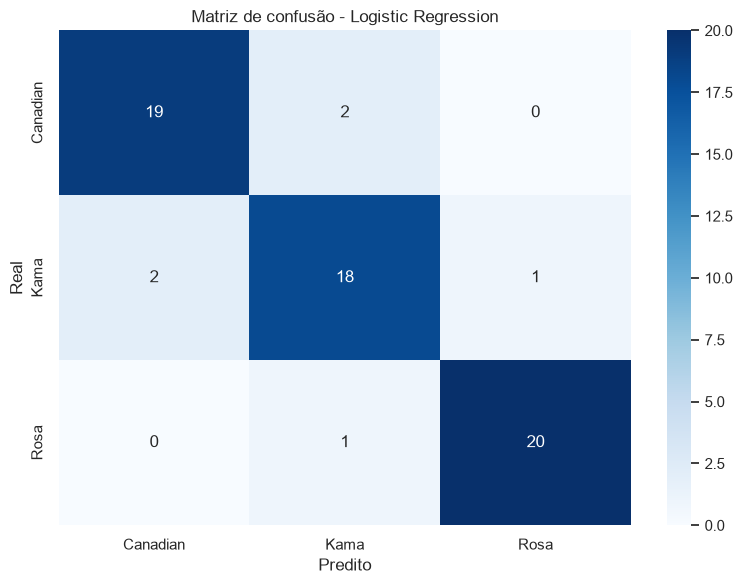

In [5]:
best_name = final_df.iloc[0]['Modelo']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)
classes = sorted(y_test.unique())

print(f'Melhor modelo no teste: {best_name}')
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de confusão - {best_name}')
plt.tight_layout()
plt.show()

## Insights e conclusões

1. **Desempenho geral**: os modelos lineares (Logistic Regression e SVM) superam os demais no dataset padronizado, indicando que as fronteiras entre as três variedades são aproximadamente lineares no espaço transformado.

2. **Melhor modelo no teste**: Regressão Logística otimizada obteve a maior acurácia no conjunto de teste. O teste t pareado entre ela e o segundo colocado (SVM) deve ser consultado na célula anterior para verificar significância estatística.

3. **Features mais discriminativas**: a Random Forest atribuiu maior importância a `perimeter`, `groove_length`, `area` e `kernel_length`. Isso indica que medidas de tamanho e formato do sulco são centrais para distinguir Kama, Rosa e Canadian.

4. **Análise de erros**: eventuais confusões entre Kama e Canadian podem ser explicadas pela proximidade de características morfológicas dessas variedades; isso sugere que, em aplicação real, amostras fronteiriças devam ser revisadas por um especialista.

5. **Impacto agrícola**: a solução permite automatizar triagem inicial de grãos em cooperativas de pequeno porte, reduzindo dependência de classificação manual e aumentando consistência. A precisão acima de 90% é suficiente para uso como primeiro filtro, com revisão humana nos casos de baixa confiança.

6. **Limitações e próximos passos**: o dataset possui apenas 210 amostras de uma única origem (Institute of Agrophysics, Polônia). Para uso produtivo no Brasil, é necessário re-treinar com variedades locais, validar em diferentes safras e adicionar uma interface de inferência.